In [5]:
import logging
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn import svm
from scipy import stats

In [6]:
# prompt: mount google drive in this ipynb

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# prompt: write code to unzip data and save it in drive

import zipfile
import os

# Define the path to the zip file in your Google Drive
zip_file_path = '/content/drive/MyDrive/FYP/data/data.zip'  # Replace with your actual path

# Define the directory where you want to extract the data
extract_path = '/content/drive/My Drive/FYP/data/unzipped' # Replace with your desired path

# Create the extract directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

try:
  with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
  print(f'Successfully unzipped {zip_file_path} to {extract_path}')
except FileNotFoundError:
  print(f'Error: Zip file not found at {zip_file_path}')
except Exception as e:
  print(f'An error occurred: {e}')


Successfully unzipped /content/drive/MyDrive/FYP/data/data.zip to /content/drive/My Drive/FYP/data/unzipped


In [8]:
# def get_train(*args):
#     x = np.load('/content/drive/MyDrive/FYP/data/unzipped/ali_train_x.npy').astype(np.float32)
#     y = np.load('/content/drive/MyDrive/FYP/data/unzipped/ali_train_y.npy').astype(np.float32)
#     # (184602, 16) (184602,)
#     # 184532 : 70
#     ind = [y==0]
#     x_train = x[ind]
#     y_train = y[ind]

#     scaler = MinMaxScaler()
#     scaler.fit(x_train)
#     scaler.transform(x_train)

#     return x_train, y_train

In [9]:
def get_train(*args):
    """Get training dataset for KDD 10 percent"""
    return _get_adapted_dataset("train")

In [10]:
def get_test(*args):
    """Get testing dataset for KDD 10 percent"""
    return _get_adapted_dataset("test")

In [11]:
def get_shape_input():
    """Get shape of the dataset for KDD 10 percent"""
    return (None, 121)


In [12]:
def get_shape_label():
    """Get shape of the labels in KDD 10 percent"""
    return (None,)

In [13]:
def _get_dataset():
    """ Gets the basic dataset
    Returns :
            dataset (dict): containing the data
                dataset['x_train'] (np.array): training images shape
                (?, 120)
                dataset['y_train'] (np.array): training labels shape
                (?,)
                dataset['x_test'] (np.array): testing images shape
                (?, 120)
                dataset['y_test'] (np.array): testing labels shape
                (?,)
    """
    col_names = _col_names()
    df = pd.read_csv("/content/drive/MyDrive/FYP/data/kddcup.data_10_percent_corrected", header=None, names=col_names)

    text_l = ['protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_host_login', 'is_guest_login']

    for name in text_l:
        _encode_text_dummy(df, name)

    labels = df['label'].copy()
    # Given the ratio of normal(less) and abnormal samples(more), suppose preponderant samples are normal
    # Isolation Tree regards the dominant labels as 1(normal), and the less as -1(abnormal)
    labels[labels != 'normal.'] = 1
    labels[labels == 'normal.'] = -1

    df['label'] = labels

    df_train = df.sample(frac=0.5, random_state=42)
    df_test = df.loc[~df.index.isin(df_train.index)]

    x_train, y_train = _to_xy(df_train, target='label')
    y_train = y_train.flatten().astype(int)
    x_test, y_test = _to_xy(df_test, target='label')
    y_test = y_test.flatten().astype(int)

    # x_train = x_train[y_train != 1]
    # y_train = y_train[y_train != 1]

    scaler = MinMaxScaler()
    scaler.fit(x_train)
    scaler.transform(x_train)
    scaler.transform(x_test)

    dataset = {}
    dataset['x_train'] = x_train.astype(np.float32)
    dataset['y_train'] = y_train.astype(np.float32)
    dataset['x_test'] = x_test.astype(np.float32)
    dataset['y_test'] = y_test.astype(np.float32)

    return dataset

In [14]:
def _get_adapted_dataset(split):
    """ Gets the adapted dataset for the experiments

    Args :
            split (str): train or test
    Returns :
            (tuple): <training, testing> images and labels
    """
    dataset = _get_dataset()
    key_img = 'x_' + split
    key_lbl = 'y_' + split

    if split != 'train':
        dataset[key_img], dataset[key_lbl] = _adapt(dataset[key_img],
                                                    dataset[key_lbl])

    return (dataset[key_img], dataset[key_lbl])


In [15]:
def _encode_text_dummy(df, name):
    """Encode text values to dummy variables(i.e. [1,0,0],[0,1,0],[0,0,1]
    for red,green,blue)
    """
    dummies = pd.get_dummies(df.loc[:,name])
    for x in dummies.columns:
        dummy_name = "{}-{}".format(name, x)
        df.loc[:, dummy_name] = dummies[x]
    df.drop(name, axis=1, inplace=True)

In [16]:
def _to_xy(df, target):
    """Converts a Pandas dataframe to the x,y inputs that TensorFlow needs"""
    result = []
    for x in df.columns:
        if x != target:
            result.append(x)
    dummies = df[target]
    return df.to_numpy().astype(np.float32), dummies.to_numpy().astype(np.float32)


In [17]:
def _col_names():
    """Column names of the dataframe 42-dim"""
    return ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label"]


In [18]:
def _adapt(x, y, rho=0.1):
    """Adapt the ratio of normal/anomalous data"""

    # Normal data: label =0, anomalous data: label =1

    rng = np.random.RandomState(42) # seed shuffling

    inliersx = x[y == 1]
    inliersy = y[y == 1]
    outliersx = x[y == -1]
    outliersy = y[y == -1]

    size_outliers = outliersx.shape[0]
    inds = rng.permutation(size_outliers)
    outliersx, outliersy = outliersx[inds], outliersy[inds]

    size_test = inliersx.shape[0]
    out_size_test = int(size_test*rho/(1-rho))
    outestx = outliersx[:out_size_test]
    outesty = outliersy[:out_size_test]

    testx = np.concatenate((inliersx,outestx), axis=0)
    testy = np.concatenate((inliersy,outesty), axis=0)

    size_test = testx.shape[0]
    inds = rng.permutation(size_test)
    testx, testy = testx[inds], testy[inds]

    return testx, testy

In [19]:
trainx, trainy = get_train()
testx, testy = get_test()

In [20]:
# # from sklearn.linear_model  import SGDOneClassSVM
# from sklearn.metrics import accuracy_score
# import numpy as np

In [21]:
# clf = SGDOneClassSVM(nu=0.95 * 0.1 + 0.05)
# clf.fit(trainx)

In [22]:
# y_pred = clf.predict(testx)

In [23]:
from sklearn.preprocessing import MinMaxScaler

# Assuming trainx and testx are your training and testing datasets
scaler = MinMaxScaler()
trainx_scaled = scaler.fit_transform(trainx)
testx_scaled = scaler.transform(testx)

# Gaussian Mixture Models (GMM)

In [24]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(trainx_scaled)

# Predicting the clusters
y_pred = gmm.predict(testx_scaled)

In [25]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming y_true are the true labels and y_pred are the predicted labels
conf_matrix = confusion_matrix(testy, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Classification report for precision, recall, and F1-score
print("Classification Report:")
print(classification_report(testy, y_pred))


Confusion Matrix:
[[     0    479  21563]
 [     0      0      0]
 [     0  55280 143102]]
Classification Report:


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        -1.0       0.00      0.00      0.00     22042
         0.0       0.00      0.00      0.00         0
         1.0       0.87      0.72      0.79    198382

    accuracy                           0.65    220424
   macro avg       0.29      0.24      0.26    220424
weighted avg       0.78      0.65      0.71    220424



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

In [26]:
# prompt: Find y_true for my dataset

y_true = testy

In [27]:
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# accuracy = accuracy_score(y_true, y_pred)
# # precision = precision_score(y_true, y_pred)
# # recall = recall_score(y_true, y_pred)
# f1 = f1_score(y_true, y_pred)

# print(f"Accuracy: {accuracy}")
# print(f"Precision: {precision}")
# print(f"Recall: {recall}")
# print(f"F1-Score: {f1}")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted') # Added average='weighted'
recall = recall_score(y_true, y_pred, average='weighted') # Added average='weighted'
f1 = f1_score(y_true, y_pred, average='weighted') # Added average='weighted'

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.6492124269589519
Precision: 0.7821459307379879
Recall: 0.6492124269589519
F1-Score: 0.7095062605391081


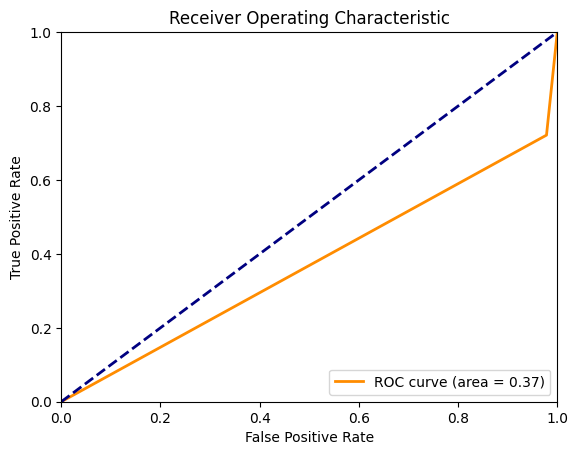

In [28]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


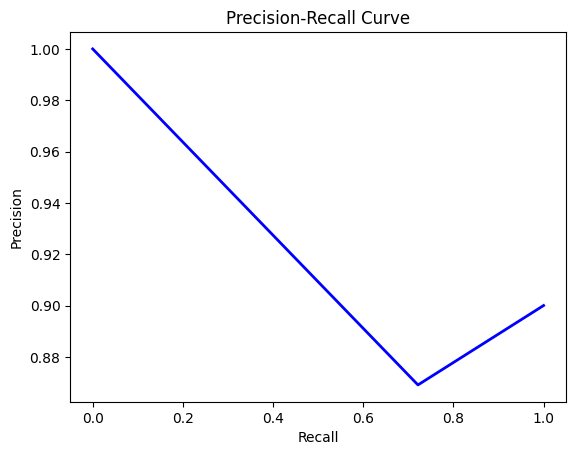

In [29]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(testy, y_pred)

plt.figure()
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


[[0.000e+00 5.200e+02 0.000e+00 ... 1.000e+00 1.000e+00 0.000e+00]
 [0.000e+00 2.312e+03 3.270e+02 ... 1.000e+00 1.000e+00 0.000e+00]
 [0.000e+00 1.032e+03 0.000e+00 ... 1.000e+00 1.000e+00 0.000e+00]
 ...
 [0.000e+00 1.032e+03 0.000e+00 ... 1.000e+00 1.000e+00 0.000e+00]
 [0.000e+00 5.200e+02 0.000e+00 ... 1.000e+00 1.000e+00 0.000e+00]
 [0.000e+00 1.032e+03 0.000e+00 ... 1.000e+00 1.000e+00 0.000e+00]]
[]


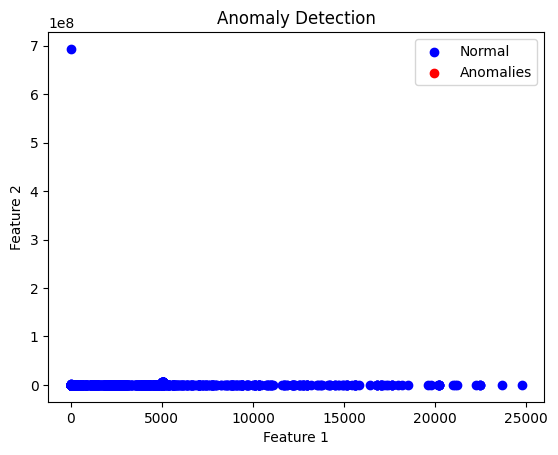

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming testx is your dataset and y_pred are the anomaly labels (-1 for anomalies, 1 for normal)
anomalies = testx[y_pred == -1]
normal = testx[y_pred == 1]
print(normal)
print(anomalies)

# Select the first two features for visualization
plt.scatter(normal[:, 0], normal[:, 1], c='blue', label='Normal')
plt.scatter(anomalies[:, 0], anomalies[:, 1], c='red', label='Anomalies')
plt.title('Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


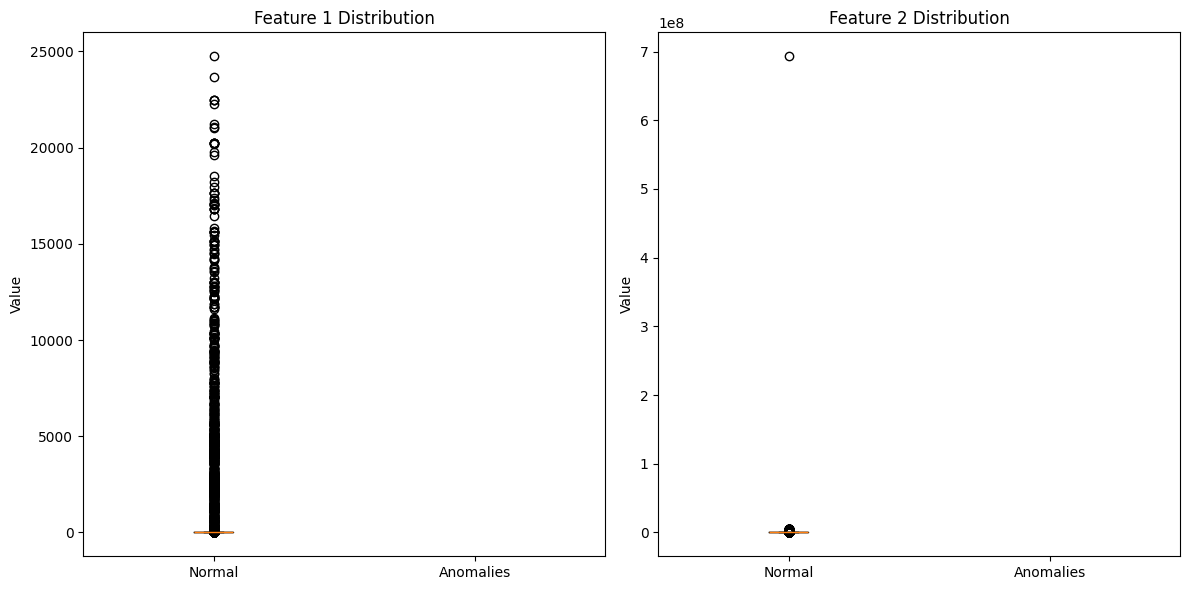

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming testx is your dataset and y_pred are the anomaly labels (-1 for anomalies, 1 for normal)
anomalies = testx[y_pred == -1]
normal = testx[y_pred == 1]

# Create a box plot for the first two features
plt.figure(figsize=(12, 6))

# Feature 1
plt.subplot(1, 2, 1)
plt.boxplot([normal[:, 0], anomalies[:, 0]], labels=['Normal', 'Anomalies'])
plt.title('Feature 1 Distribution')
plt.ylabel('Value')

# Feature 2
plt.subplot(1, 2, 2)
plt.boxplot([normal[:, 1], anomalies[:, 1]], labels=['Normal', 'Anomalies'])
plt.title('Feature 2 Distribution')
plt.ylabel('Value')

plt.tight_layout()
plt.show()


In [33]:
# prompt: Write code for me to save the model of robust co variance that i have trained

import joblib

# Save the trained model to a file
joblib.dump(gmm, 'gmm.joblib')

['gmm.joblib']